# 1. Import and paths

In [1]:
#Steps: upload data, split in train/test, pre-process ->feed PANN
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython.display import display

from panns_inference import AudioTagging

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)


/home/basti/code/Kitty3000-ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Set paths for import
ROOT = Path("/home/basti/code/Kitty3000-ML")
DATA_DIR = ROOT / "data" / "CatSound_originals"
MANIFEST_PATH = ROOT / "data" / "manifest.csv"

In [3]:
# Allow imports from src/ when running inside notebooks/.
sys.path.insert(0, str(ROOT / "src"))
from kitty3000_ml.preprocess import load_clip, N_FFT, HOP_LENGTH

In [4]:
#Set SR to 32000 as requirement (todo: check details) and seconds to 11 for now (experiment later)
SR = 32000
SECONDS = 11.0

BATCH_SIZE = 1

#model name - experiment with seconds
RUN_NAME = f"panns_cnn14_{SR}hz_{SECONDS:g}s"

#set output directory
OUTPUT_DIR = ROOT / "data" / "processed" / RUN_NAME
MODEL_DIR = ROOT / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
# Load the existing manifest.
manifest = pd.read_csv(MANIFEST_PATH, dtype=str)

# Build paths for audio loading.
manifest["full_path"] = manifest["path"].map(lambda p: DATA_DIR / p)

In [6]:
manifest.head()

,path,label,group,split,full_path
0,Angry/Cat_Angry1026.mp3,Angry,Angry/cat_angry1026,train,/home/basti/code/Kitty3000-ML/data/CatSound_or...
1,Angry/Cat_Angry1027.mp3,Angry,Angry/cat_angry1027,train,/home/basti/code/Kitty3000-ML/data/CatSound_or...
2,Angry/Cat_Angry1028.mp3,Angry,Angry/cat_angry1028,test,/home/basti/code/Kitty3000-ML/data/CatSound_or...
3,Angry/Cat_Angry1029.mp3,Angry,Angry/cat_angry1029,train,/home/basti/code/Kitty3000-ML/data/CatSound_or...
4,Angry/Cat_Angry1030.mp3,Angry,Angry/cat_angry1030,val,/home/basti/code/Kitty3000-ML/data/CatSound_or...


# 2. Load PANN model

In [7]:
#Load pre-trained model with default learning weights
pann = AudioTagging(checkpoint_path=None)

#test: select one training data point
sample_path = manifest.loc[
    manifest["split"] == "train", "full_path"
].iloc[0]

#load recording with SR and Seconds, format 32-bit floating
#32000 sampels/second for 7 seconds = 224,000 samples
waveform = load_clip(
    sample_path,
    sr=SR,
    seconds=SECONDS,
).astype(np.float32)

#use inference on waveform
#returns audioset_scores (527 categories) and sample_embeddings /2048) ->input for classifier later
audioset_scores, sample_embedding = pann.inference(waveform[None, :])

print("Waveform:", waveform.shape)              # (224000,)
print("AudioSet scores:", audioset_scores.shape) # (1, 527)
print("Embedding:", sample_embedding.shape)      # (1, 2048)

Checkpoint path: /home/basti/panns_data/Cnn14_mAP=0.431.pth


Using CPU.
Waveform: (352000,)
AudioSet scores: (1, 527)
Embedding: (1, 2048)


In [8]:
#Now that I loaded PANN with all parameters and tried it on one test sample, lets apply it to the entire dataset
#go through each row and create the 2048 features for each audio sample

embeddings = []

#this is just for fun to see what the PANN would classify
predicted_scores = []

#Go through each audio/row, load clip with parameters, infer score and embedding
for path in tqdm(manifest["full_path"], desc="Extracting features"):
    waveform = load_clip(
        path, sr=SR, seconds=SECONDS
    ).astype(np.float32)

    scores, embedding = pann.inference(waveform[None, :])

    embeddings.append(embedding)
    predicted_scores.append(scores[0])

#contains all embeddings in same order as the full_path
X = np.concatenate(embeddings, axis=0)

# One row per recording, one column per AudioSet category.
scores_df = pd.DataFrame(
    predicted_scores,
    columns=pann.labels,
)

# Separate table containing metadata and the highest-scoring prediction.
predictions_df = manifest[
    ["path", "label", "group", "split"]
].reset_index(drop=True).copy()

predictions_df["panns_prediction"] = scores_df.idxmax(axis=1)
predictions_df["panns_score"] = scores_df.max(axis=1)

display(predictions_df.head())

Extracting features:  30%|███       | 895/2953 [08:40<32:14,  1.06it/s]Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Extracting features: 100%|██████████| 2953/2953 [30:40<00:00,  1.60it/s]


,path,label,group,split,panns_prediction,panns_score
0,Angry/Cat_Angry1026.mp3,Angry,Angry/cat_angry1026,train,Screaming,0.256932
1,Angry/Cat_Angry1027.mp3,Angry,Angry/cat_angry1027,train,Speech,0.836324
2,Angry/Cat_Angry1028.mp3,Angry,Angry/cat_angry1028,test,Speech,0.737406
3,Angry/Cat_Angry1029.mp3,Angry,Angry/cat_angry1029,train,Speech,0.517119
4,Angry/Cat_Angry1030.mp3,Angry,Angry/cat_angry1030,val,"Domestic animals, pets",0.673358


In [14]:
#add code to store the embeddings
EMB_DIR = ROOT / "data" / "embeddings"
EMB_DIR.mkdir(parents=True, exist_ok=True)
EMB_PATH = EMB_DIR / f"{RUN_NAME}.npz"

np.savez(
    EMB_PATH,
    X=X,
    y=manifest["label"].to_numpy(),
    split=manifest["split"].to_numpy(),
    path=manifest["path"].to_numpy(),
    group=manifest["group"].to_numpy(),
    audioset_scores=scores_df.to_numpy().astype(np.float32),
    sr=SR,
    seconds=SECONDS,
)
print("Saved:", EMB_PATH, X.shape)

Saved: /home/basti/code/Kitty3000-ML/data/embeddings/panns_cnn14_32000hz_11s.npz (2953, 2048)


# 3. Train, validate, test 

In [9]:
y = manifest["label"].to_numpy()

#Split manifest according to the 3 classes train, val, test
train_mask = manifest["split"].eq("train").to_numpy()
val_mask = manifest["split"].eq("val").to_numpy()
test_mask = manifest["split"].eq("test").to_numpy()

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (2058, 2048)
Val:   (448, 2048)
Test:  (447, 2048)


In [10]:
results = []
best_score = -1.0

#Create pipeline and run Logistic Regression with 4 different C values
#the smaller C, the highe the regularization ->lets check validation later for optimal C
for C in [0.01, 0.1, 1.0, 10.0]:
    candidate = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C, max_iter=2000),
    )

    #fit with training data only
    candidate.fit(X_train, y_train)

    #predict with validation data
    val_pred = candidate.predict(X_val)

    #calculate F1 based on validation set
    score = f1_score(
        y_val, val_pred, average="macro", zero_division=0
    )

    results.append({
        "C": C,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_macro_f1": score,
    })

    if score > best_score:
        classifier = candidate
        best_score = score
        best_C = C

display(
    pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
)

print(f"Selected C={best_C} | Validation macro F1={best_score:.3f}")

,C,val_accuracy,val_macro_f1
0,0.01,0.830357,0.830386
1,0.10,0.830357,0.829930
2,1.00,0.823661,0.824008
3,10.00,0.805804,0.806328


Selected C=0.01 | Validation macro F1=0.830


In [11]:
#Create overview of probabilities per class ->this is wahat should be exported
val_probabilities = pd.DataFrame(
    classifier.predict_proba(X_val),
    columns=classifier.classes_,
    index=manifest.index[val_mask],
)

display(val_probabilities.head())

,Angry,Defence,Fighting,Happy,HuntingMind,Mating,MotherCall,Paining,Resting,Warning
4,0.810473,0.000735,0.004081,0.005458,0.001829,0.025593,0.001730,0.009438,0.002110,0.138554
5,0.919989,0.000531,0.001339,0.001792,0.000153,0.005918,0.001787,0.003365,0.000621,0.064506
22,0.865330,0.000051,0.000180,0.000151,0.000020,0.011422,0.000206,0.000874,0.000367,0.121399
25,0.972459,0.000426,0.000681,0.002680,0.000115,0.012588,0.000219,0.000579,0.000276,0.009977
45,0.963951,0.000023,0.000218,0.000168,0.000018,0.021270,0.000034,0.000542,0.000196,0.013581


In [12]:
#Export the classification model to model path
#Important: does not include the PANN model for feature creation
MODEL_PATH = MODEL_DIR / f"{RUN_NAME}_classifier.joblib"

joblib.dump({
    "classifier": classifier, #final classifier (logistic model so far)
    "sr": SR, #audio sampling rate used to train the model
    "seconds": SECONDS, #audio window duration used
    "crop_n_fft": N_FFT,
    "crop_hop_length": HOP_LENGTH, #file_name e.g.  Cnn14_mAP=0.431.pth
    "panns_checkpoint": "Cnn14_mAP=0.431.pth",
}, MODEL_PATH)

print("Saved:", MODEL_PATH)

Saved: /home/basti/code/Kitty3000-ML/models/panns_cnn14_32000hz_11s_classifier.joblib


Test accuracy: 0.834
Test macro F1: 0.833
              precision    recall  f1-score   support

       Angry      0.870     0.889     0.879        45
     Defence      0.870     0.909     0.889        44
    Fighting      0.796     0.867     0.830        45
       Happy      0.714     0.667     0.690        45
 HuntingMind      0.935     0.977     0.956        44
      Mating      0.783     0.800     0.791        45
  MotherCall      0.851     0.889     0.870        45
     Paining      0.674     0.705     0.689        44
     Resting      1.000     1.000     1.000        45
     Warning      0.853     0.644     0.734        45

    accuracy                          0.834       447
   macro avg      0.834     0.835     0.833       447
weighted avg      0.835     0.834     0.833       447



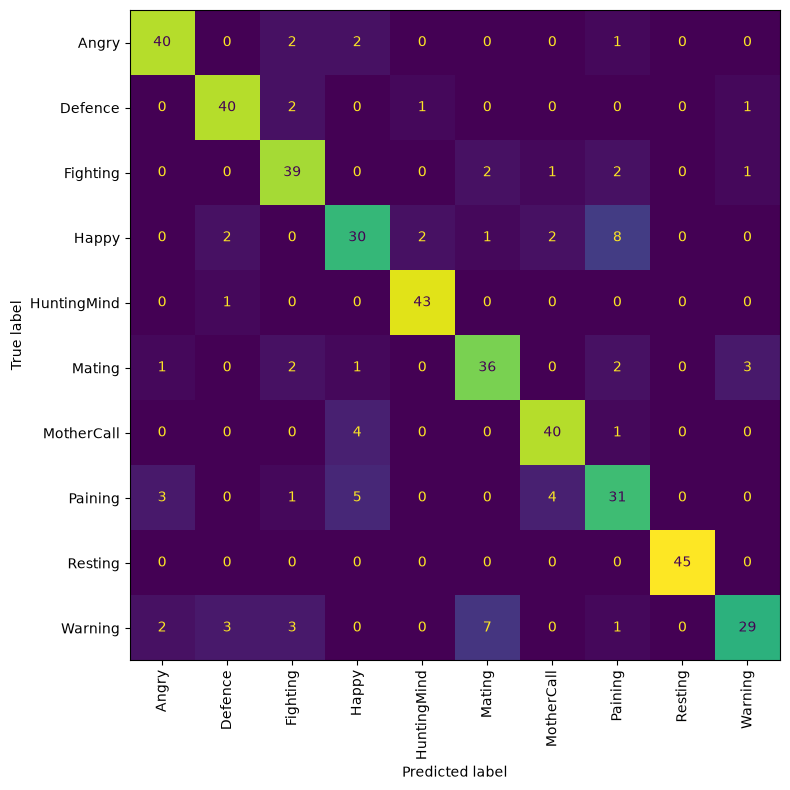

In [13]:
#Final test run
RUN_FINAL_TEST = True

if RUN_FINAL_TEST:
    test_pred = classifier.predict(X_test)

    print(f"Test accuracy: {accuracy_score(y_test, test_pred):.3f}")
    print(
        f"Test macro F1: "
        f"{f1_score(y_test, test_pred, average='macro', zero_division=0):.3f}"
    )

    print(classification_report(
        y_test,
        test_pred,
        labels=classifier.classes_,
        digits=3,
        zero_division=0,
    ))

    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_pred,
        labels=classifier.classes_,
        xticks_rotation=90,
        colorbar=False,
        ax=ax,
    )
    plt.tight_layout()
    plt.show()

else:
    print("Finish validation before enabling final test evaluation.")

In [ ]:
'''
from pathlib import Path
from pprint import pprint
from kitty3000_ml.predict import predict_updated

# Pick one validation recording.
example = manifest.loc[manifest["split"] == "val"].iloc[0]
audio_path = Path(DATA_DIR) / example["path"]

# Read the encoded audio file into bytes.
wav_bytes = audio_path.read_bytes()

# Call the same function your API will use.
result = predict_updated(wav_bytes=wav_bytes, model_name="panns")

print("File:", audio_path.name)
print("Dataset label:", example["label"])
print("Predicted label:", result["label"])
pprint(result)
'''

File: Cat_Angry1030.mp3
Dataset label: Angry
Predicted label: Angry
{'label': 'Angry',
 'model': 'panns',
 'probs': {'Angry': 0.8104729056358337,
           'Defence': 0.0007352296379394829,
           'Fighting': 0.004080748651176691,
           'Happy': 0.005458060186356306,
           'HuntingMind': 0.001829393208026886,
           'Mating': 0.025593018159270287,
           'MotherCall': 0.0017301930347457528,
           'Paining': 0.009437591768801212,
           'Resting': 0.002109610242769122,
           'Warning': 0.13855323195457458}}
